In [9]:
import torch
import torchvision
from matplotlib import pyplot as plt
from torch.nn import Module, Conv2d, ReLU
from torchvision.datasets import MNIST

In [17]:
class MyConvModel(Module):
    def __init__(self, pattern:list[int]=None, in_channels:int=3):
        super().__init__()
        pattern = pattern if pattern is not None else []
        pattern.append(in_channels)

        convs = torch.nn.ModuleList()
        for i in range(1, len(pattern)):
            convs.append(
                Conv2d(
                    in_channels=pattern[i-1],
                    out_channels=pattern[i],
                    kernel_size=3,
                    stride=1,
                )
            )
            convs.append(ReLU())
        self.convs = convs


    def forward(self, x):
        for l in self.convs:
            x = l(x)
        return x

CM = MyConvModel(
    pattern=[16, 32, 64],
    in_channels=1,
)
CM

MyConvModel(
  (convs): ModuleList(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
  )
)

In [18]:
ds = MNIST(root="./data", download=True)

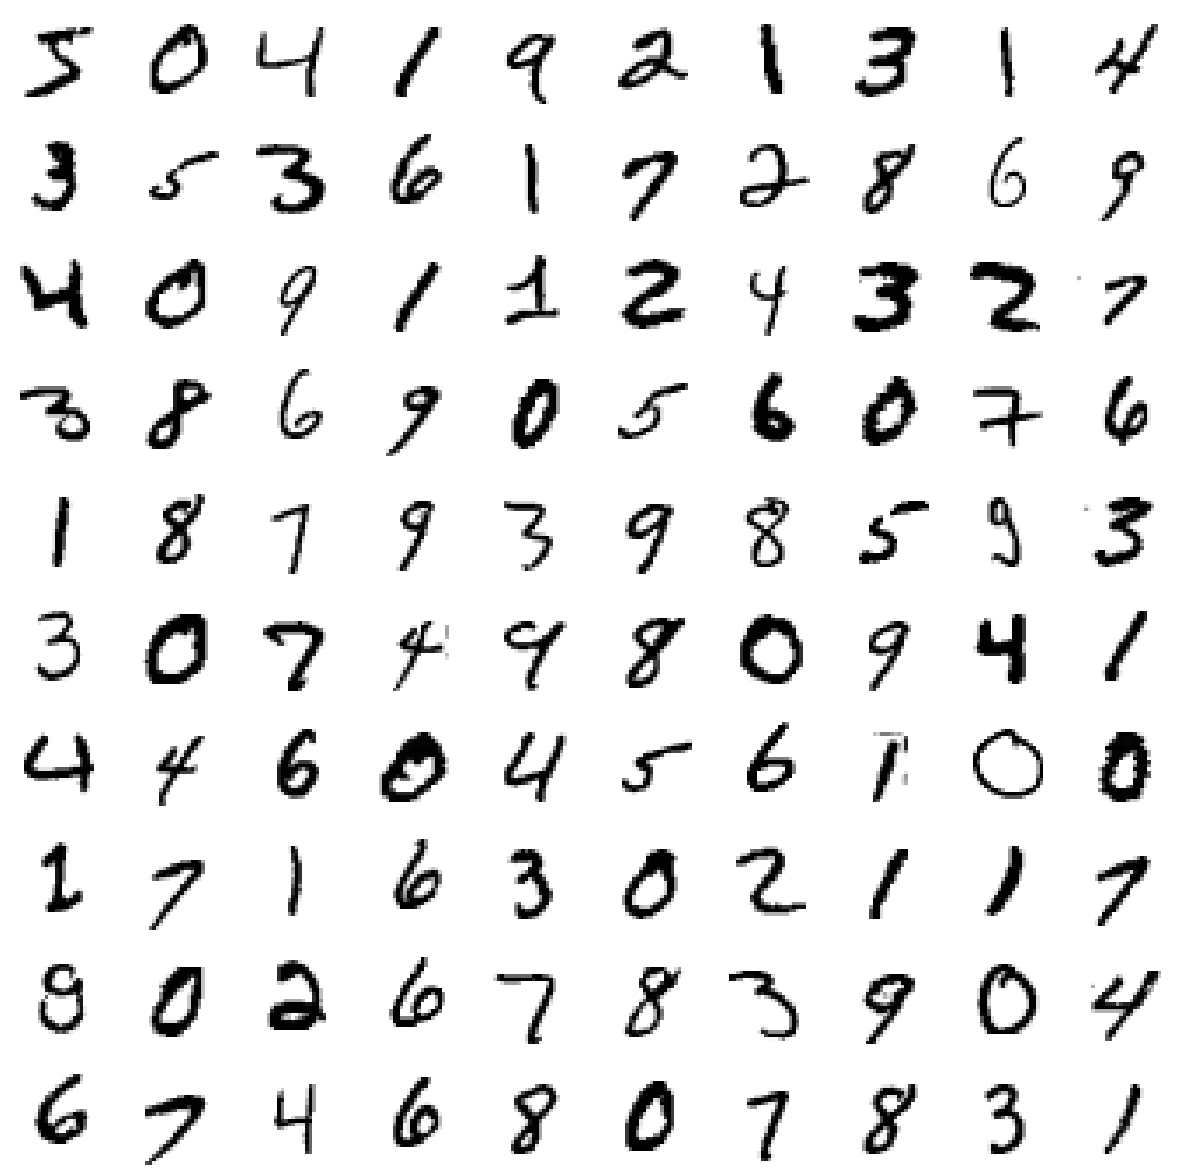

In [19]:
size = 10
fig, axs = plt.subplots(
    ncols=size,
    nrows=size,
    figsize=(15, 15),
)
for i in range(size*size):
    x, y = ds[i]
    axs[i//size,i%size].imshow(x, cmap="gray_r")
    axs[i//size,i%size].axis('off')


In [25]:
from torchvision.models import vgg19, VGG19_Weights
from torchvision.models import resnet101

In [26]:
model = resnet101(pretrained=True)
model

/home/nikita/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/nikita/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /home/nikita/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth
100%|██████████| 171M/171M [00:15<00:00, 11.6MB/s] 


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [28]:
pc = 0
for p in model.parameters():
    pc += p.numel()

pc

44549160